In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt
from src.commons import data_loader

# 1. Optimize JupyterLab display aesthetics

In [3]:
pl.Config.set_tbl_rows(15)
pl.Config.set_tbl_cols(12)
pl.Config.set_float_precision(4)

polars.config.Config

# 2. Open an un-materialized high-performance file stream pointer

In [4]:
df = data_loader.read_csv("substation.csv")

# 3. Data Profiling

In [5]:
# 3.1.  Substation Schema
print("---Substation Data Schema Preview ---")
print(df.schema)

---Substation Data Schema Preview ---
Schema([('Substation ID', String), ('Substation Type', String), ('Location', String), ('Voltage KV', Float64), ('Source Type', String), ('Source ID', String), ('Scada ID', String)])


In [6]:
# 3,2. Substation Data Shape & Describe Preview
print("--- Substation Data Shape and Describe Preview ---")
print(df.glimpse())

--- Substation Data Shape and Describe Preview ---
Rows: 500
Columns: 7
$ Substation ID   <str> 'SUB-0001', 'SUB-0002', 'SUB-0003', 'SUB-0004', 'SUB-0005', 'SUB-0006', 'SUB-0007', 'SUB-0008', 'SUB-0009', 'SUB-0010'
$ Substation Type <str> 'Step-down', 'Step-down', 'Distribution', 'Transmission', 'Step-up', 'Step-down', 'Step-down', 'Transmission', 'Transmission', 'Transmission'
$ Location        <str> 'District 80', 'District 119', 'District 3', 'District 80', 'District 17', 'District 78', 'District 75', 'District 11', 'District 82', 'District 107'
$ Voltage KV      <f64> 138.0, 138.0, 500.0, 230.0, 69.0, 13.8, 13.8, 230.0, 34.5, 500.0
$ Source Type     <str> 'POWER_PLANT', 'RENEWABLE_SOURCE', 'ENERGY_STORAGE', 'ENERGY_STORAGE', 'ENERGY_STORAGE', 'ENERGY_STORAGE', 'ENERGY_STORAGE', 'POWER_PLANT', 'POWER_PLANT', 'POWER_PLANT'
$ Source ID       <str> 'PP-0004', 'RS-0024', 'ES-0017', 'ES-0009', 'ES-0005', 'ES-0020', 'ES-0006', 'PP-0018', 'PP-0014', 'PP-0021'
$ Scada ID        <str> 'SCD-0

# 4. Count missing values in parallel across millions of records

In [33]:
# Create a comprehensive audit summary
total_rows = df.height
null_counts = df.select(pl.all().is_null().sum())
null_pcts = df.select((pl.all().is_null().sum() / total_rows * 100).round(2))

# Reshape them vertically using unpivot
counts_vertical = null_counts.unpivot(variable_name="Column", value_name="Null Count")
pcts_vertical = null_pcts.unpivot(variable_name="Column", value_name="Null Percentage (%)")

# Join them together by the Column name
audit_df = counts_vertical.join(pcts_vertical, on="Column").sort("Null Count", descending=True)

print(audit_df)

shape: (7, 3)
┌─────────────────┬────────────┬─────────────────────┐
│ Column          ┆ Null Count ┆ Null Percentage (%) │
│ ---             ┆ ---        ┆ ---                 │
│ str             ┆ u32        ┆ f64                 │
╞═════════════════╪════════════╪═════════════════════╡
│ Substation ID   ┆ 0          ┆ 0.0000              │
│ Substation Type ┆ 0          ┆ 0.0000              │
│ Location        ┆ 0          ┆ 0.0000              │
│ Voltage KV      ┆ 0          ┆ 0.0000              │
│ Source Type     ┆ 0          ┆ 0.0000              │
│ Source ID       ┆ 0          ┆ 0.0000              │
│ Scada ID        ┆ 0          ┆ 0.0000              │
└─────────────────┴────────────┴─────────────────────┘


# 5 Plotting chart about metrics generated from the exploration.

In [34]:
# 5.1.. Calculate the metrics
total_rows = df.height

# Count actual Polars 'null' values across all columns
total_nulls = df.select(pl.all().is_null().sum()).sum_horizontal().item()


# Count empty strings ("") which often represent missing text data
string_cols = [col for col, dtype in df.schema.items() if dtype == pl.String]
if string_cols:
    total_empty_strings = df.select(pl.col(string_cols).eq("").sum()).sum_horizontal().item()
else:
    total_empty_strings = 0

In [35]:
# 5.2.. Setup data for plotting
metrics = ['Total Rows', 'Null Values', 'Missing (Empty Strings)']
counts = [total_rows, total_nulls, total_empty_strings]
colors = ['#1f77b4', '#ff7f0e', '#d62728'] # Blue, Orange, Red

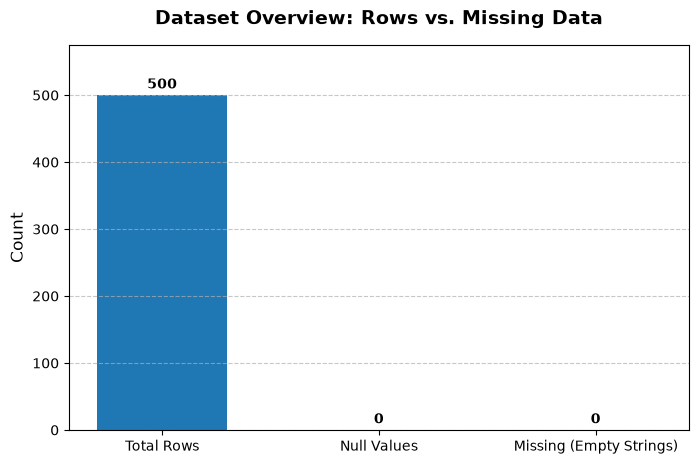

In [36]:
# 5.3. Generate the plot
plt.figure(figsize=(8, 5))
bars = plt.bar(metrics, counts, color=colors, width=0.6)

# Add exact value labels on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + (total_rows * 0.01), 
             f'{yval:,}', ha='center', va='bottom', fontweight='bold')

plt.title('Dataset Overview: Rows vs. Missing Data', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Count', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adjust y-limit to give space for labels
plt.ylim(0, max(counts) * 1.15)

plt.show()

In [7]:
%pwd

'/workspace/notebooks'